In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/newG15/')
from util import *
from copy import deepcopy
from tqdm import tqdm

In [2]:
from glob import glob
sub_names = glob("/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/newG15/drift_6/sub_baseline_once/G15_drift_6_arcdrift-M*-specs_T-bld.hdf5")
sub2 = h5py.File(sub_names[16],'r')

freq = sub2['freq'][:]

In [3]:
T = get_data(sub2,polar='average')

In [4]:
T_ori = deepcopy(T)

# time RFI

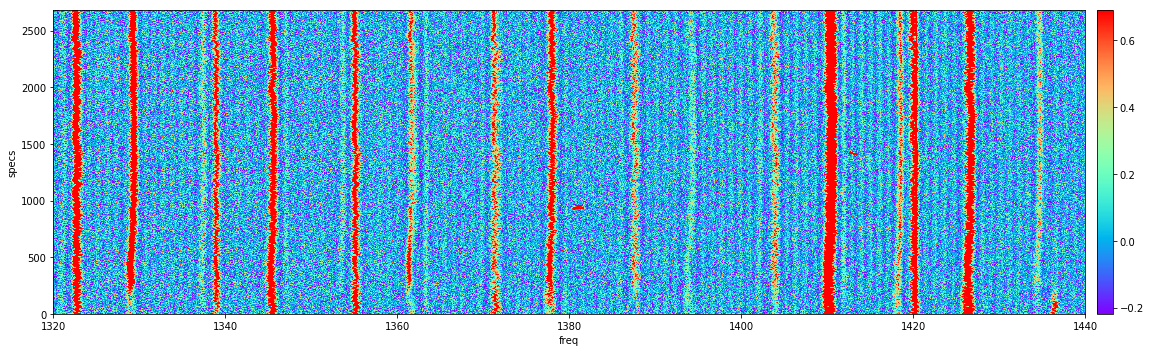

In [5]:
plot_waterfall(sub2,data = T,per_vmin_max=.90,figsize=(18,5))

start end 判断延续时间，起始点与周围点差值

In [5]:
from markRFI import mask_time_rfi

Looking for short-freq time RFI in [1380, 1382] ...
Finish


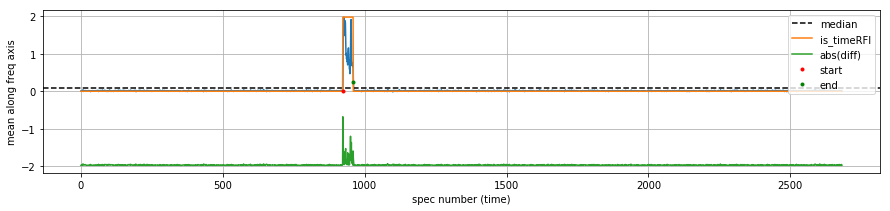

In [6]:
s_rfi = mask_time_rfi(T,freq,T_thr = .3, rtype = 'short-freq',frange =[1380,1382],times = 10,thr = 10,
                      ext_add=0,rfi_width_lim =20,plot = True)

In [7]:
l_rfi = mask_time_rfi(T,freq, rtype = 'long-freq',frange =[1400,1500],times = 1.5,thr = 0,
                      ext_add=10,rfi_width_lim =50,plot = True)

Looking for long-freq time RFI ...
No long-freq time rfi is found.


In [8]:
t_rfi = l_rfi|s_rfi
T[t_rfi] = np.nan

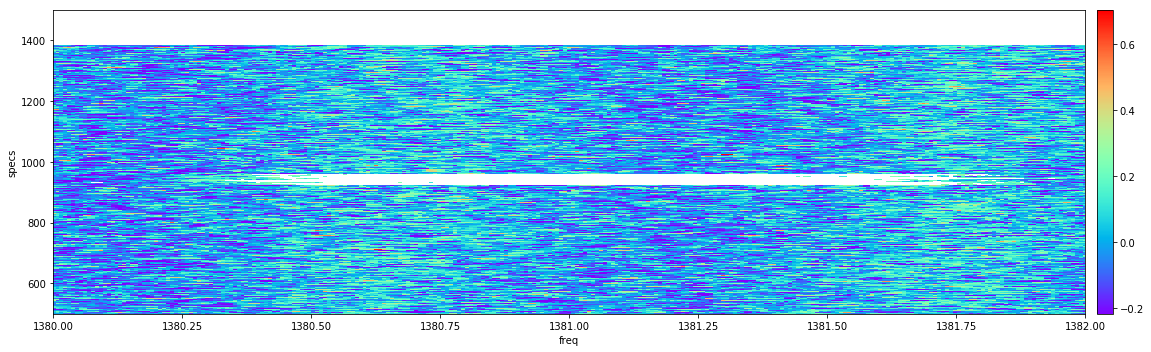

In [8]:
plot_waterfall(sub2,data = T,per_vmin_max=.90,figsize=(18,5),xylim=[1380,1382,500,1500])

In [9]:
T = deepcopy(T_ori)
T[s_rfi] = 0

In [10]:
whole_rfi = np.all(t_rfi,axis = 1)
not_rfi_num = np.arange(T.shape[0])[~whole_rfi]
is_rfi_num = np.arange(T.shape[0])[whole_rfi]

In [11]:
len(is_rfi_num)

0

In [11]:
T = np.delete(T,is_rfi_num,axis = 0)

In [ ]:
plot_waterfall(sub2,data = T,per_vmin_max=.90,figsize=(18,5))

## smooth

In [12]:
s_method_freq='gaussian' 
s_sigma_freq =3 
s_method_t ='boxcar' 
s_sigma_t = 7
from hifast.util import smooth1d
if  s_method_t in ['gaussian', 'boxcar', 'median']:
    T = smooth1d(T,axis = 0,sigma = s_sigma_t, method = s_method_t)

if  s_method_freq in ['gaussian', 'boxcar', 'median']:
    T = smooth1d(T,axis = 1,sigma = s_sigma_freq, method = s_method_freq)

In [16]:
T_ = np.full(T_ori.shape,np.nan)
T_[not_rfi_num,:] = T
T = deepcopy(T_)

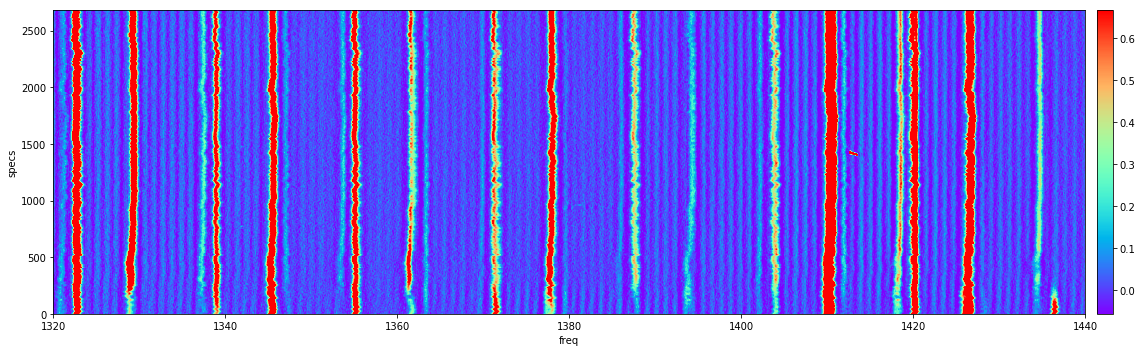

In [17]:
plot_waterfall(sub2,data = T,per_vmin_max=.90,figsize=(18,5))

# freq period RFI

In [13]:
from markRFI import rms,find_RFI,find_center

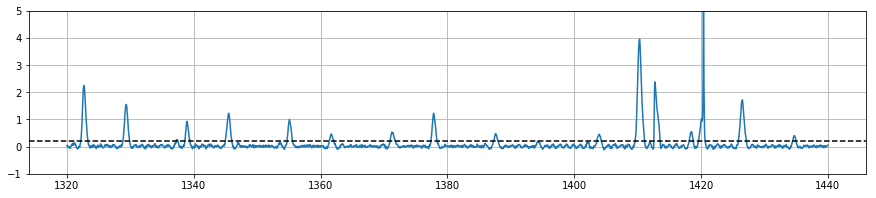

In [14]:
tn = 1420
spec = deepcopy(T[tn,:])
freq = sub2['freq'][:]

RMS = rms(spec,freq,[1400,1403])
thr = 3*RMS

plt.figure(figsize=(15,3))
plt.plot(freq,spec)
plt.axhline(thr,linestyle = '--',color = 'k')
plt.grid()
plt.ylim(-1,5)

mw_range = [1419,1425]
protect_use = (freq>mw_range[0])&(freq<mw_range[1])
is_rfi = (spec>thr)&(~protect_use)
is_rfi_mw = (spec>thr)

In [20]:
fcenter1,fcenter2,fcenter3,fc0 = find_center(spec,freq,is_rfi,RMS,freq_step = 8.1,
                                            rfi_width_lim=20,ext_sec = 20,freq_thr = .3)

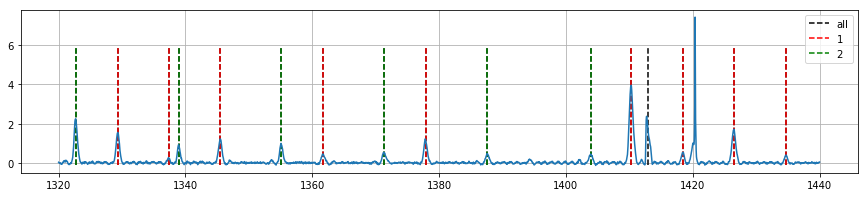

In [21]:
fig,ax = plt.subplots(figsize=(15,3))
ax.plot(freq,spec)
ymin = np.min(spec);ymax = np.max(spec)*.8
ax.vlines(fc0,ymin=ymin,ymax=ymax,linestyles='--',colors='k',label = 'all')
ax.vlines(fcenter1,ymin=ymin,ymax=ymax,linestyles='--',colors='r',label = '1')
ax.vlines(fcenter2,ymin=ymin,ymax=ymax,linestyles='--',colors='g',label = '2')
plt.grid();plt.legend()

这种mask不干净，但是可以保留在小rfi上的源

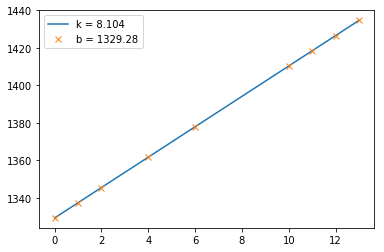

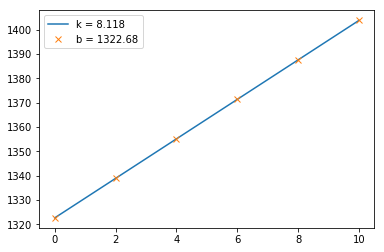

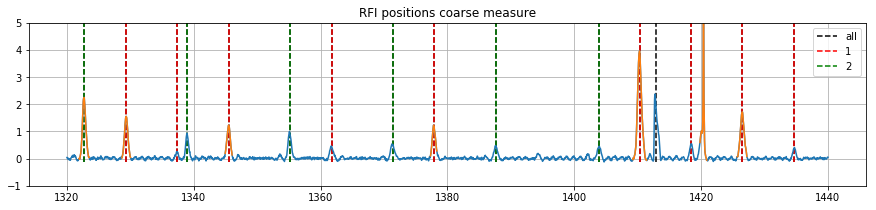

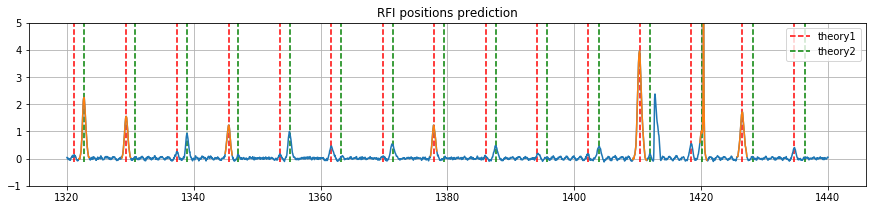

In [19]:
pd_rfi,theory = find_RFI(spec,freq,is_rfi,is_rfi_mw ,ext_edge=10,plot =True,ylim=(-1,5),
                  rfi_width_lim=20,ext_sec = 20,RMS=RMS,rfi_fit_use='two groups',freq_thr = .3,mask_thr=15)

这样标记很干净，但是扔掉太多了

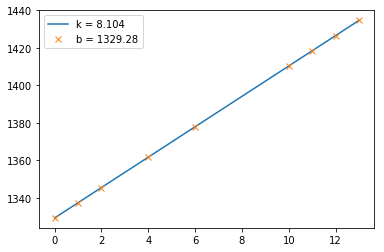

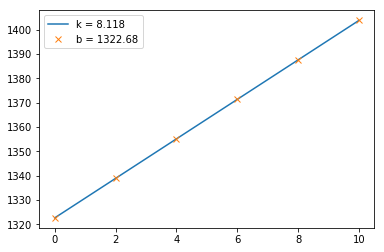

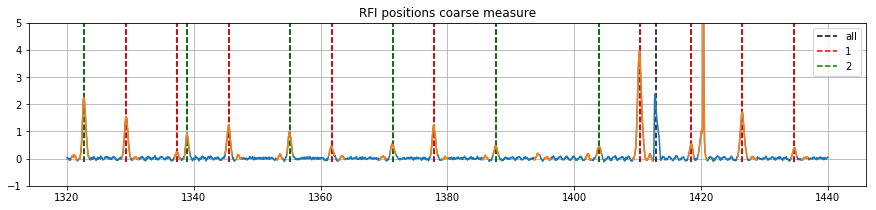

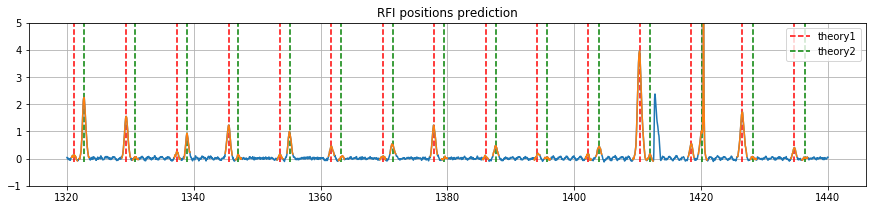

In [22]:
pd_rfi,theory = find_RFI(spec,freq,is_rfi,is_rfi_mw ,ext_edge=10,plot =True,ylim=(-1,5),
                  rfi_width_lim=20,ext_sec = 20,RMS=RMS,rfi_fit_use='two groups',freq_thr = .3,
                       mask_all_theory = True, freq_from_theory =.5)